In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [47]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhadramohit/credit-card-fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-fraud-detection' dataset.
Path to dataset files: /kaggle/input/credit-card-fraud-detection


In [48]:
import os

print(os.listdir(path))

['credit_card_fraud_dataset.csv']


In [49]:
import pandas as pd

file_path = os.path.join(path, "credit_card_fraud_dataset.csv")
df = pd.read_csv(file_path)

print(df.head())
print(df.shape)

   TransactionID             TransactionDate   Amount  MerchantID  \
0              1  2024-04-03 14:15:35.462794  4189.27         688   
1              2  2024-03-19 13:20:35.462824  2659.71         109   
2              3  2024-01-08 10:08:35.462834   784.00         394   
3              4  2024-04-13 23:50:35.462850  3514.40         944   
4              5  2024-07-12 18:51:35.462858   369.07         475   

  TransactionType      Location  IsFraud  
0          refund   San Antonio        0  
1          refund        Dallas        0  
2        purchase      New York        0  
3        purchase  Philadelphia        0  
4        purchase       Phoenix        0  
(100000, 7)


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [51]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionID    100000 non-null  int64         
 1   TransactionDate  100000 non-null  datetime64[ns]
 2   Amount           100000 non-null  float64       
 3   MerchantID       100000 non-null  int64         
 4   TransactionType  100000 non-null  object        
 5   Location         100000 non-null  object        
 6   IsFraud          100000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 5.3+ MB


In [53]:
df['TransactionType'].unique()

array(['refund', 'purchase'], dtype=object)

In [54]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['TransactionType'] = le.fit_transform(df['TransactionType'])

In [55]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'purchase': np.int64(0), 'refund': np.int64(1)}


In [56]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,1,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,1,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,0,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,0,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,0,Phoenix,0


In [57]:
df['Location'].unique()

array(['San Antonio', 'Dallas', 'New York', 'Philadelphia', 'Phoenix',
       'Chicago', 'San Jose', 'San Diego', 'Houston', 'Los Angeles'],
      dtype=object)

In [58]:
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

In [59]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,IsFraud,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,1,2024-04-03 14:15:35.462794,4189.27,688,1,0,False,False,False,False,False,False,True,False,False
1,2,2024-03-19 13:20:35.462824,2659.71,109,1,0,True,False,False,False,False,False,False,False,False
2,3,2024-01-08 10:08:35.462834,784.00,394,0,0,False,False,False,True,False,False,False,False,False
3,4,2024-04-13 23:50:35.462850,3514.40,944,0,0,False,False,False,False,True,False,False,False,False
4,5,2024-07-12 18:51:35.462858,369.07,475,0,0,False,False,False,False,False,True,False,False,False


In [60]:
df.drop('TransactionID', axis=1, inplace=True)

In [61]:
df['Hour'] = df['TransactionDate'].dt.hour
df['Day'] = df['TransactionDate'].dt.day
df['Month'] = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

df.drop('TransactionDate', axis=1, inplace=True)

In [62]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Amount                 100000 non-null  float64
 1   MerchantID             100000 non-null  int64  
 2   TransactionType        100000 non-null  int64  
 3   IsFraud                100000 non-null  int64  
 4   Location_Dallas        100000 non-null  int64  
 5   Location_Houston       100000 non-null  int64  
 6   Location_Los Angeles   100000 non-null  int64  
 7   Location_New York      100000 non-null  int64  
 8   Location_Philadelphia  100000 non-null  int64  
 9   Location_Phoenix       100000 non-null  int64  
 10  Location_San Antonio   100000 non-null  int64  
 11  Location_San Diego     100000 non-null  int64  
 12  Location_San Jose      100000 non-null  int64  
 13  Hour                   100000 non-null  int32  
 14  Day                    100000 non-nul

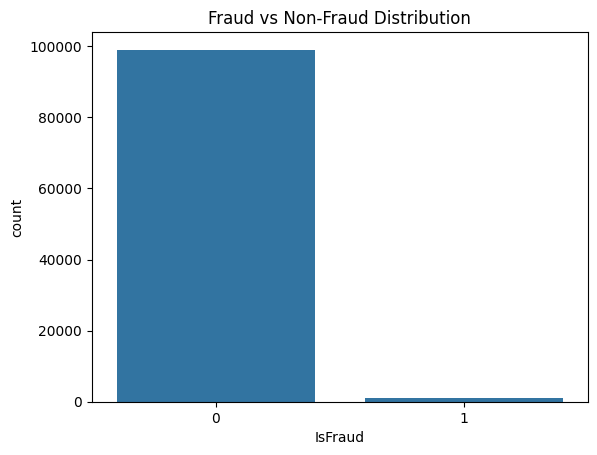

IsFraud
0    0.99
1    0.01
Name: proportion, dtype: float64


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='IsFraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print(df['IsFraud'].value_counts(normalize=True))

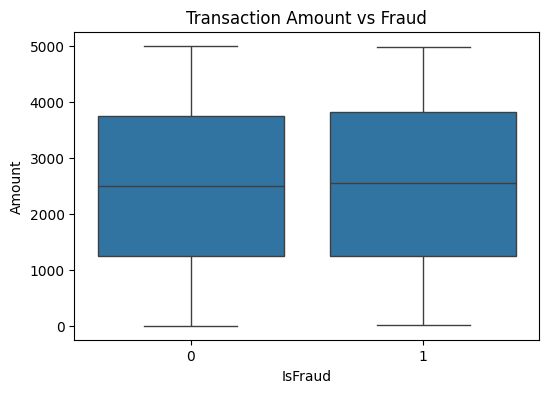

In [65]:
plt.figure(figsize=(6,4))
sns.boxplot(x='IsFraud', y='Amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

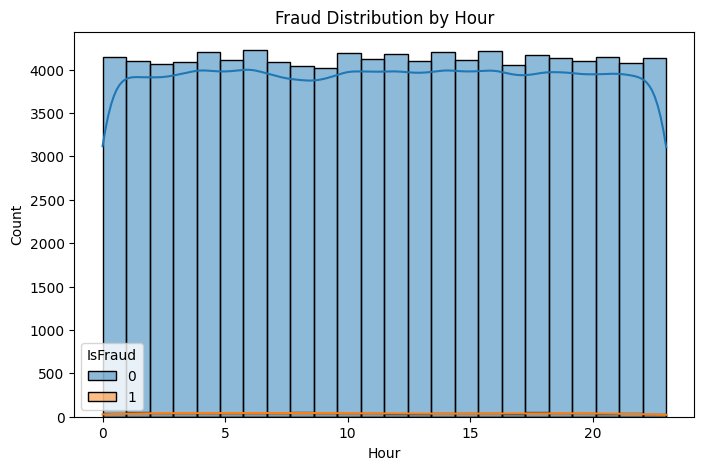

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Hour', hue='IsFraud', bins=24, kde=True)
plt.title("Fraud Distribution by Hour")
plt.show()

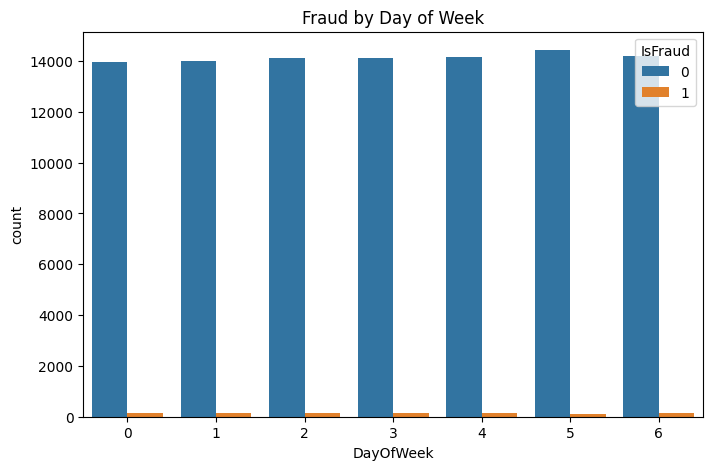

In [67]:
plt.figure(figsize=(8,5))
sns.countplot(x='DayOfWeek', hue='IsFraud', data=df)
plt.title("Fraud by Day of Week")
plt.show()

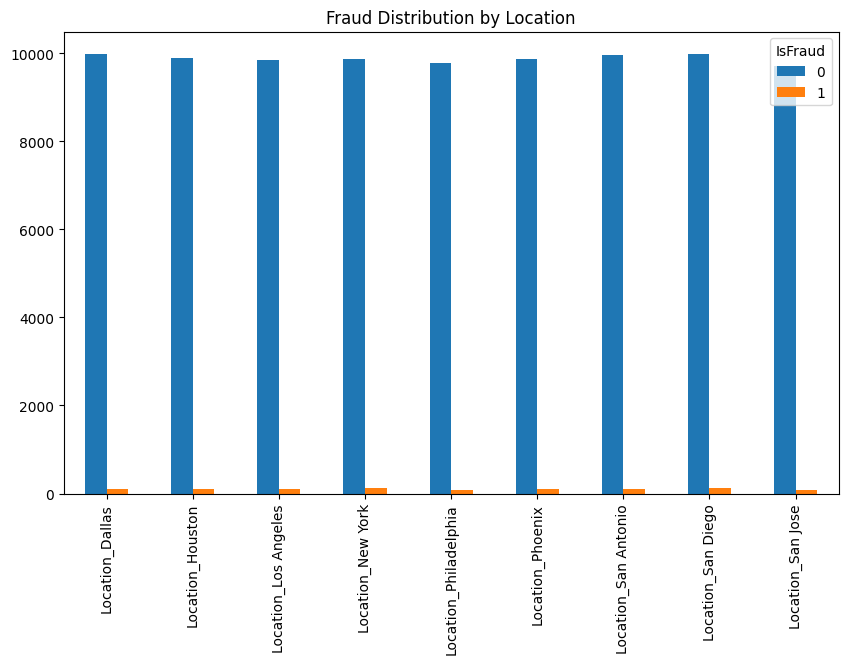

In [68]:
location_cols = [col for col in df.columns if 'Location_' in col]

df_location = df.groupby('IsFraud')[location_cols].sum().T

df_location.plot(kind='bar', figsize=(10,6))
plt.title("Fraud Distribution by Location")
plt.show()

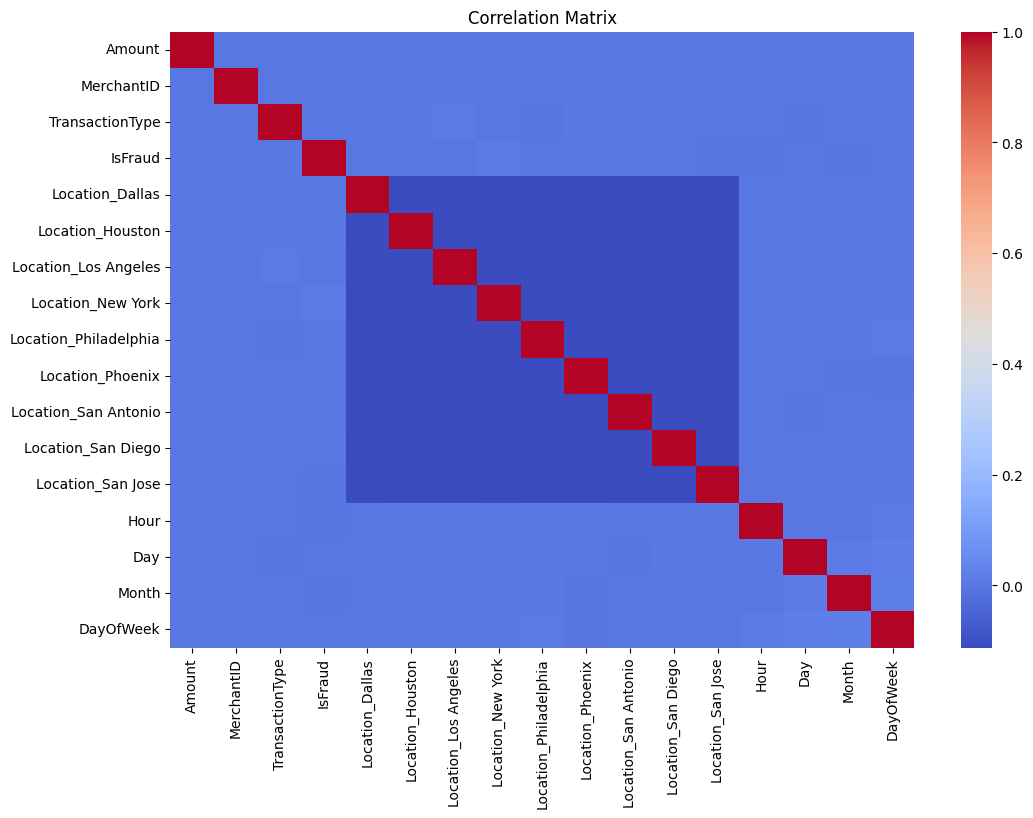

In [69]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

/tmp/ipykernel_4125/2732633929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TransactionType', y='FraudRate', data=fraud_by_type, palette='Reds_d')


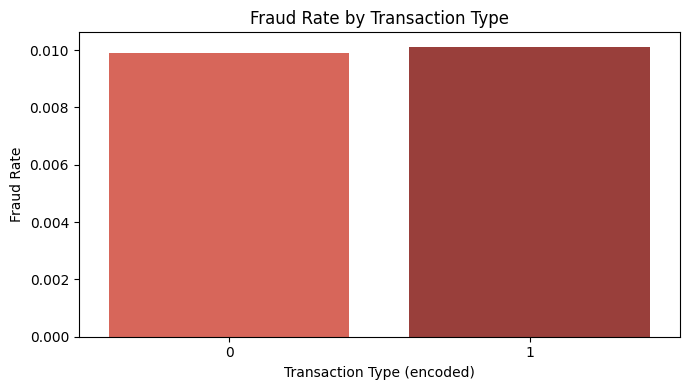

In [70]:
fraud_by_type = df.groupby('TransactionType')['IsFraud'].mean().reset_index()
fraud_by_type.columns = ['TransactionType', 'FraudRate']

plt.figure(figsize=(7, 4))
sns.barplot(x='TransactionType', y='FraudRate', data=fraud_by_type, palette='Reds_d')
plt.title('Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.xlabel('Transaction Type (encoded)')
plt.tight_layout()
plt.show()

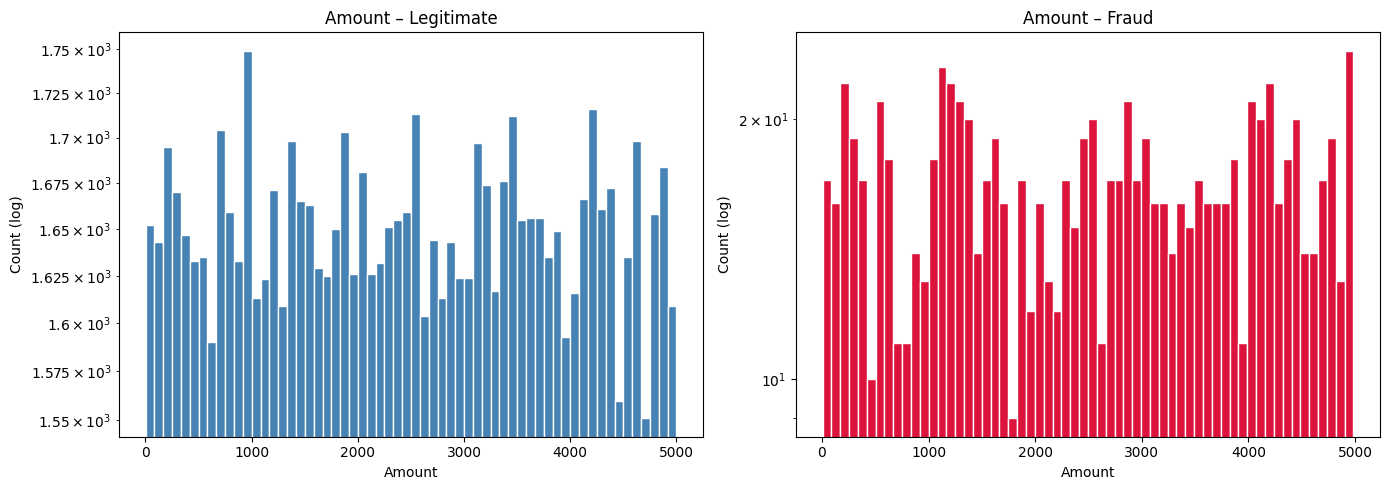

Amount statistics by class:
           count        mean          std   min        25%      50%       75%  \
IsFraud                                                                         
0        99000.0  2496.88992  1442.257175  1.05  1247.9550  2495.61  3742.855   
1         1000.0  2517.16444  1458.643653  5.56  1249.2775  2543.43  3813.850   

             max  
IsFraud           
0        4999.77  
1        4985.88  


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, ax in zip([0, 1], axes):
    subset = df[df['IsFraud'] == label]['Amount']
    ax.hist(subset, bins=60, color='steelblue' if label == 0 else 'crimson', edgecolor='white')
    ax.set_title(f'Amount – {"Legitimate" if label == 0 else "Fraud"}')
    ax.set_xlabel('Amount')
    ax.set_ylabel('Count (log)')
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

print('Amount statistics by class:')
print(df.groupby('IsFraud')['Amount'].describe())

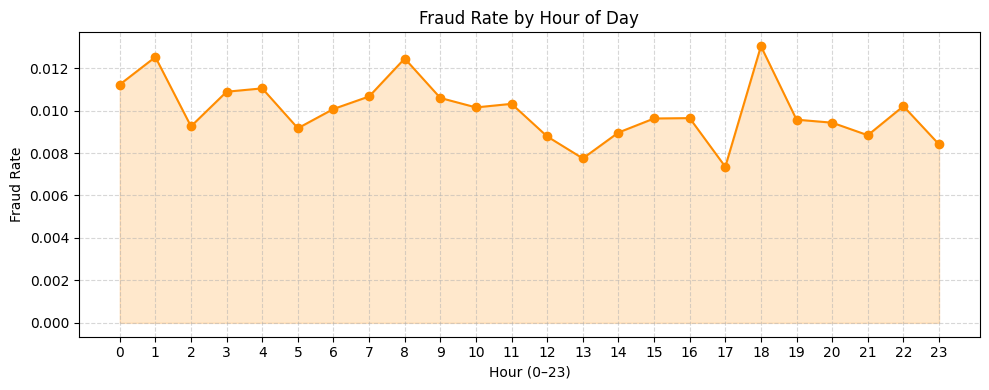

In [72]:
fraud_by_hour = df.groupby('Hour')['IsFraud'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(fraud_by_hour['Hour'], fraud_by_hour['IsFraud'], marker='o', color='darkorange')
plt.fill_between(fraud_by_hour['Hour'], fraud_by_hour['IsFraud'], alpha=0.2, color='darkorange')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0–23)')
plt.ylabel('Fraud Rate')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4125/1503135245.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='IsFraud', data=fraud_by_month, palette='YlOrRd')


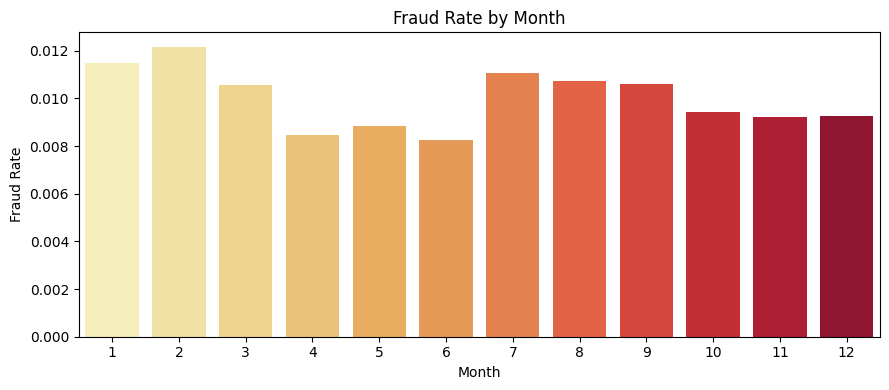

In [73]:
fraud_by_month = df.groupby('Month')['IsFraud'].mean().reset_index()

plt.figure(figsize=(9, 4))
sns.barplot(x='Month', y='IsFraud', data=fraud_by_month, palette='YlOrRd')
plt.title('Fraud Rate by Month')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

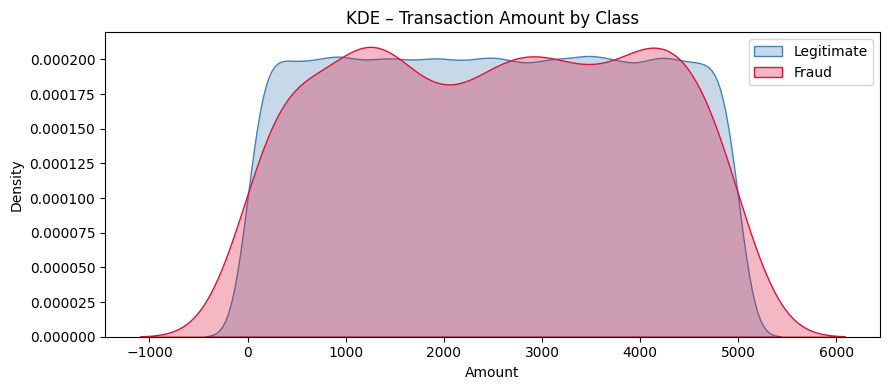

In [74]:
plt.figure(figsize=(9, 4))
for label, color, name in zip([0, 1], ['steelblue', 'crimson'], ['Legitimate', 'Fraud']):
    sns.kdeplot(df[df['IsFraud'] == label]['Amount'],
                label=name, color=color, fill=True, alpha=0.3)
plt.title('KDE – Transaction Amount by Class')
plt.xlabel('Amount')
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
Q1  = df['Amount'].quantile(0.25)
Q3  = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Amount'] < Q1 - 1.5*IQR) | (df['Amount'] > Q3 + 1.5*IQR)]

print(f'Total outliers (IQR on Amount) : {len(outliers)}')
print(f'Fraud rate among outliers       : {outliers["IsFraud"].mean():.4f}')
print(f'Fraud rate overall              : {df["IsFraud"].mean():.4f}')

Total outliers (IQR on Amount) : 0
Fraud rate among outliers       : nan
Fraud rate overall              : 0.0100


In [76]:
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

IsFraud
0    79213
1    79213
Name: count, dtype: int64


In [80]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [81]:
results = []

for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print(classification_report(y_test, y_pred))

    results.append((name, acc, roc))


===== Logistic Regression =====
Accuracy: 0.52615
ROC-AUC: 0.4852246851503726
              precision    recall  f1-score   support

           0       0.99      0.53      0.69     19787
           1       0.01      0.49      0.02       213

    accuracy                           0.53     20000
   macro avg       0.50      0.51      0.35     20000
weighted avg       0.98      0.53      0.68     20000


===== Decision Tree =====
Accuracy: 0.9707
ROC-AUC: 0.4975410658726707
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     19787
           1       0.01      0.01      0.01       213

    accuracy                           0.97     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.97      0.97     20000


===== Random Forest =====
Accuracy: 0.9884
ROC-AUC: 0.48496084236081394
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19787
           1 

In [82]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'ROC-AUC']).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  ROC-AUC
      Decision Tree   0.97070 0.497541
Logistic Regression   0.52615 0.485225
      Random Forest   0.98840 0.484961


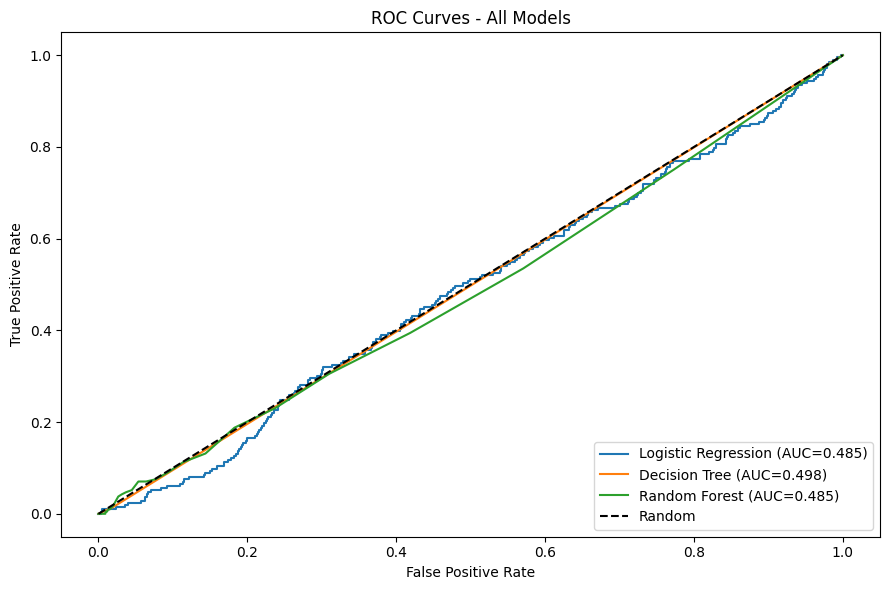

In [83]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


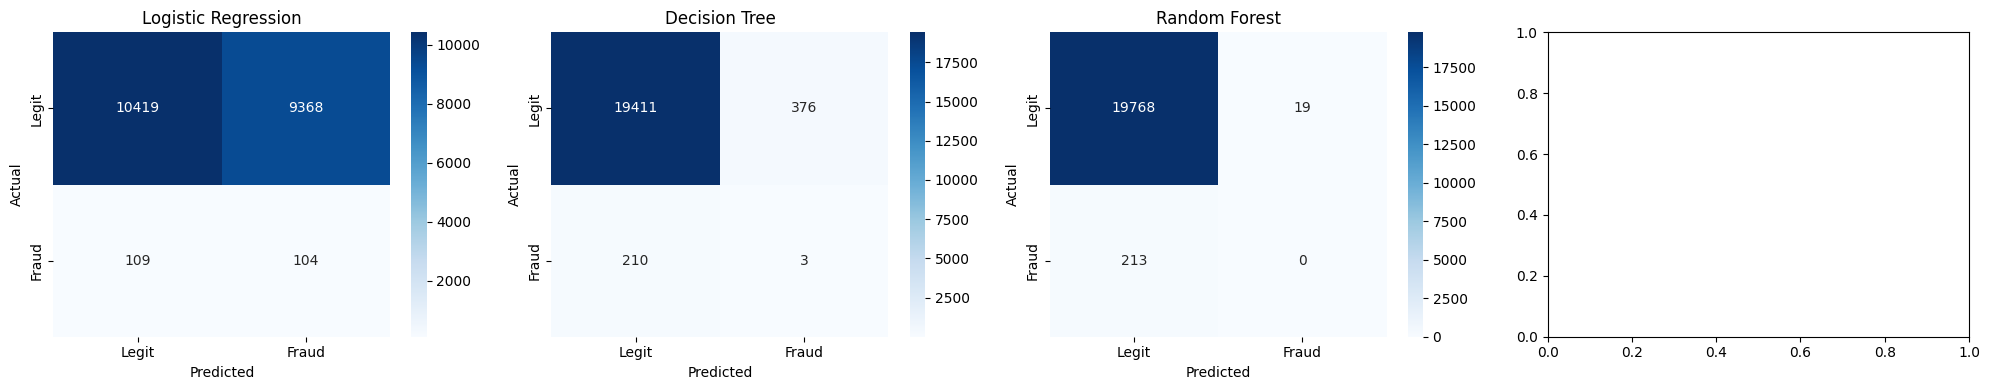

In [84]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [90]:
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

def recall_m(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    pp = K.sum(K.round(K.clip(y_true, 0, 1)))
    return tp / (pp + K.epsilon())

def precision_m(y_true, y_pred):
    tp  = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    ptp = K.sum(K.round(K.clip(y_pred, 0, 1)))
    return tp / (ptp + K.epsilon())

def f1_m(y_true, y_pred):
    p = precision_m(y_true, y_pred)
    r = recall_m(y_true, y_pred)
    return 2 * (p * r) / (p + r + K.epsilon())


In [94]:
input_dim = X_train.shape[1]

ann = Sequential([
    Dense(256, input_dim=input_dim, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 48,513 (189.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [95]:
history = ann.fit(
    X_train, y_train,
    epochs=60,
    batch_size=512,
    validation_split=0.15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)

Epoch 1/60
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6005 - loss: 0.6672 - val_accuracy: 0.8972 - val_loss: 0.5715 - learning_rate: 0.0010
Epoch 2/60
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6624 - loss: 0.6025 - val_accuracy: 0.8454 - val_loss: 0.5175 - learning_rate: 0.0010
Epoch 3/60
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6924 - loss: 0.5723 - val_accuracy: 0.8671 - val_loss: 0.4700 - learning_rate: 0.0010
Epoch 4/60
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7157 - loss: 0.5454 - val_accuracy: 0.8876 - val_loss: 0.4126 - learning_rate: 0.0010
Epoch 5/60
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7357 - loss: 0.5197 - val_accuracy: 0.9044 - val_loss: 0.3670 - learning_rate: 0.0010
Epoch 6/60
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7502 - loss: 0.4986 - val_accuracy: 0.9150 - val_loss: 0.3363 - learning_rate: 0.0010
Epoch 7/60
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7653 - loss: 0.4792 

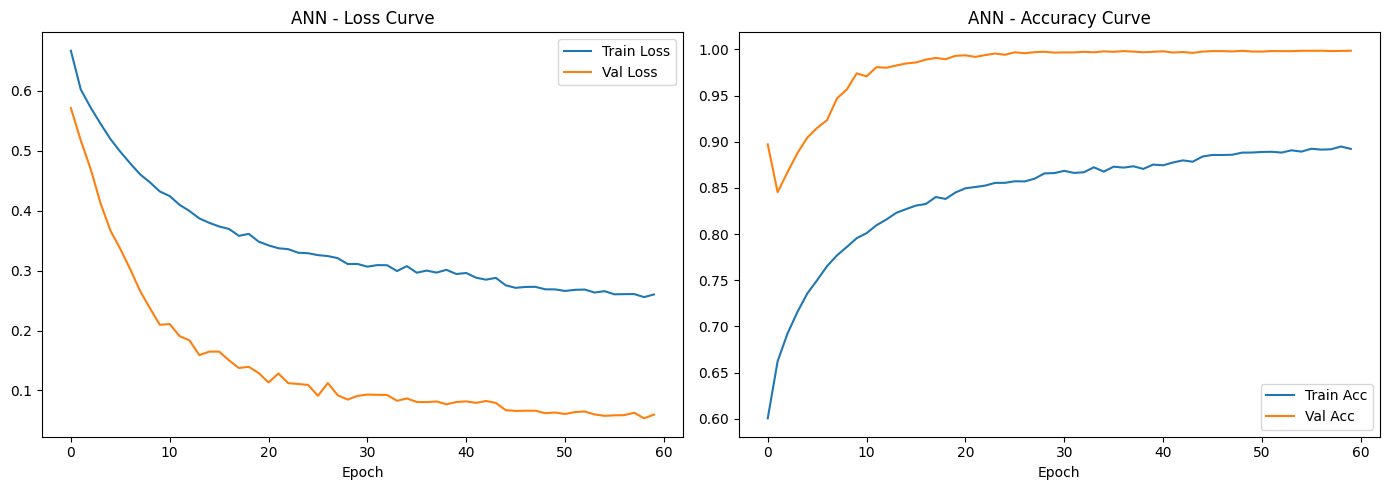

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN - Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('ANN - Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimal threshold: 0.8286
ANN  ROC-AUC  : 0.4907
ANN  F1-Score : 0.0247
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     19787
           1       0.01      0.08      0.02       213

    accuracy                           0.94     20000
   macro avg       0.50      0.51      0.50     20000
weighted avg       0.98      0.94      0.96     20000



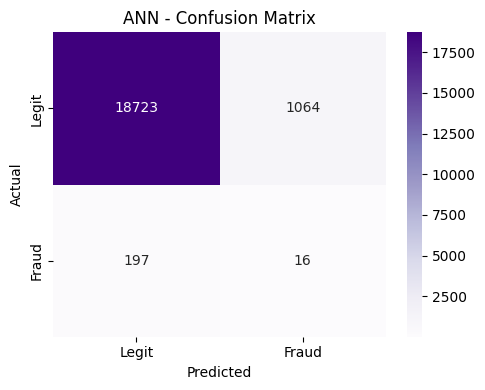

In [106]:
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
import numpy as np

y_prob_ann = ann.predict(X_test).ravel()

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_ann)
f1_scores_t = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores_t)]
print(f'Optimal threshold: {best_thresh:.4f}')

y_pred_ann = (y_prob_ann >= best_thresh).astype(int)

roc_ann = roc_auc_score(y_test, y_prob_ann)
acc_ann = accuracy_score(y_test, y_pred_ann)

print(f'ANN  ROC-AUC  : {roc_ann:.4f}')
print(f'ANN  F1-Score : {f1_score(y_test, y_pred_ann):.4f}')
print(classification_report(y_test, y_pred_ann))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_ann), annot=True, fmt='d',
            cmap='Purples', xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
plt.title('ANN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
results.append(("ANN", acc_ann, roc_ann))


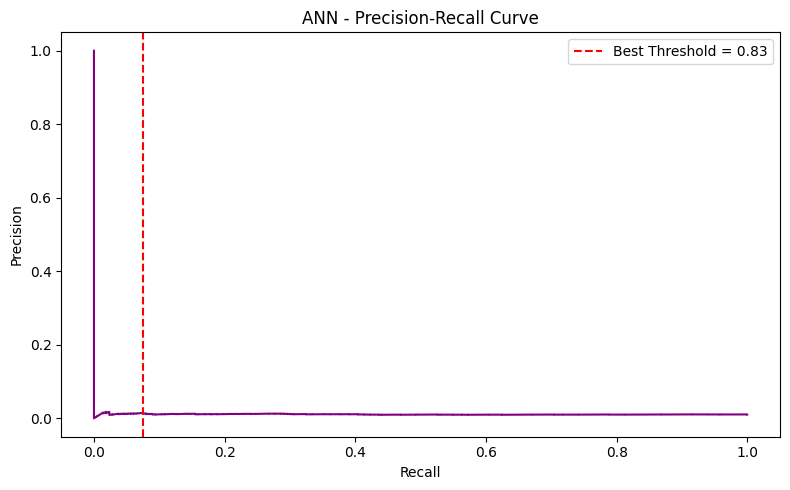

In [107]:
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='purple')
plt.axvline(x=recalls[np.argmax(f1_scores_t)], color='red', linestyle='--',
            label=f'Best Threshold = {best_thresh:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('ANN - Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [108]:
import joblib, os
os.makedirs('saved_models', exist_ok=True)

# Assign the best performing ML model (Decision Tree based on ROC-AUC) to a variable
best_ml_model = models['Decision Tree'] # update if another model wins or is tuned

joblib.dump(best_ml_model, 'saved_models/best_ml_model.pkl')
joblib.dump(scaler,      'saved_models/scaler.pkl')
joblib.dump(best_thresh, 'saved_models/ann_threshold.pkl')
ann.save('saved_models/ann_model.h5')

print('Saved: best_ml_model.pkl | scaler.pkl | ann_threshold.pkl | ann_model.h5')


Saved: best_ml_model.pkl | scaler.pkl | ann_threshold.pkl | ann_model.h5


In [109]:
def predict_fraud(transaction_dict, use_ann=False):
    import joblib
    sc     = joblib.load('saved_models/scaler.pkl')
    inp_sc = sc.transform(pd.DataFrame([transaction_dict]))

    if use_ann:
        from tensorflow.keras.models import load_model
        thresh = joblib.load('saved_models/ann_threshold.pkl')
        m = load_model('saved_models/ann_model.h5',
                       custom_objects={'f1_m': f1_m,
                                       'precision_m': precision_m,
                                       'recall_m': recall_m})
        prob  = float(m.predict(inp_sc)[0][0])
        label = 'Fraud' if prob >= thresh else 'Legitimate'
    else:
        m     = joblib.load('saved_models/best_ml_model.pkl')
        prob  = float(m.predict_proba(inp_sc)[0][1])
        label = 'Fraud' if prob >= 0.5 else 'Legitimate'

    return {'Prediction': label, 'Fraud Probability': round(prob, 4)}


# Demo
sample = dict(zip(df.drop('IsFraud', axis=1).columns, X_test[0]))
print('ML  :', predict_fraud(sample, use_ann=False))
print('ANN :', predict_fraud(sample, use_ann=True))

ML  : {'Prediction': 'Fraud', 'Fraud Probability': 1.0}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
ANN : {'Prediction': 'Legitimate', 'Fraud Probability': 0.0}


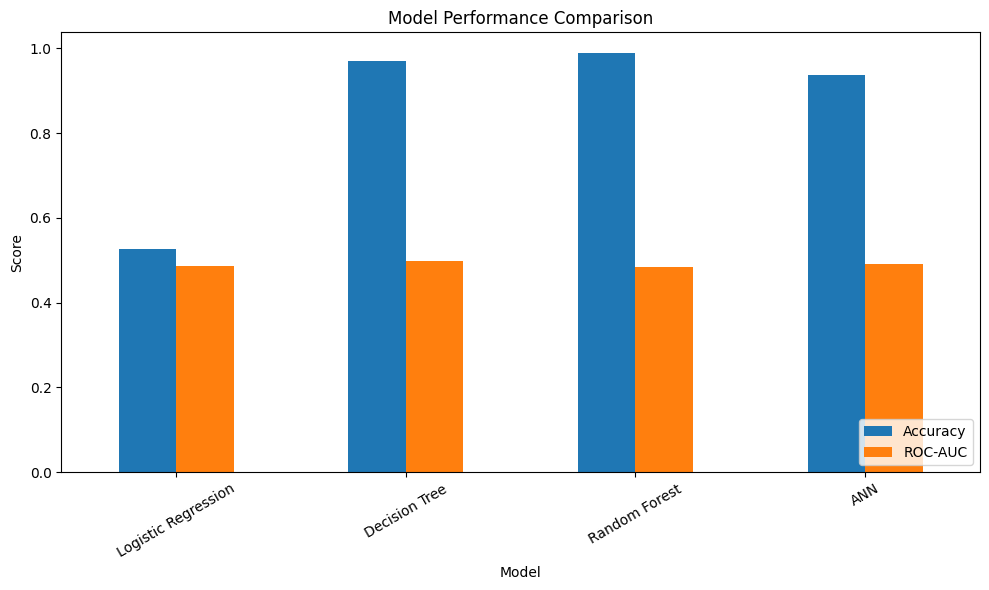

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])

results_df.set_index("Model", inplace=True)

results_df.plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()